MACHINE LEARNING BASED PHISHING AND SCAM MESSAGE DETECTION

Import required libraries

In [1]:
import pandas as pd
import numpy as np

import re

import matplotlib.pyplot as plt
import seaborn as sns


# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


import joblib

import os

Load Datatsets

In [2]:
# Dataset 1
df1 = pd.read_csv(
    "datasets/combined label dataset.csv"
)

# Dataset 2
df2 = pd.read_csv(
    "datasets/smishing dataset.csv"
)

# Dataset 3
df3 = pd.read_csv(
    "datasets/sms phishing.csv"
)


print("Datasets loaded successfully")

Datasets loaded successfully


Inspect Datasets

In [3]:
df1.head(5)

,message,spam label,smishing label
0,CANCLE,1,0
1,Your plan Smallie.is going to be renewed. Plea...,1,0
2,Dear Glo subscriber,1,0
3,Welcome to Smallie. It will expire on 04/09/20...,1,0
4,Info,1,0


In [4]:
df2.head(5)

,time,sender_id,telephone_number_type,original_network_name,original_network_country,text,translation,language,url_shortener,named_entity,scam_type,lure_principles
0,2023-05-19,phone number,BAD_FORMAT,NaN,NaN,"Desculpe, nao conseguimos encontra-lo hoje (<D...","Sorry, we couldn't find you <DATE_TIME> (<DATE...",Portuguese,NaN,NaN,delivery,"distraction,time/urgency"
1,2023-05-06,phone number,MOBILE,KPN Mobile The Netherlands B.V.,NLD,"Uw openstaande schuld van EURO 429,00 met kenm...",Your outstanding debt of EURO 429.00 with refe...,Dutch,NaN,NaN,others,"authority,time/urgency"
2,2023-05-02,phone number,BAD_FORMAT,NaN,NaN,Tentamos entregar a sua encomenda hoje dia <DA...,We tried to deliver your package <DATE_TIME> o...,Portuguese,NaN,NaN,delivery,time/urgency
3,2023-04-07,phone number,MOBILE,Movistar,ESP,"Correos Express, su paquete sigue retenido en ...","Correos Express, your package is still held up...",Spanish,cutt.ly,Correos,delivery,"authority,time/urgency"
4,2023-03-23,phone number,LANDLINE,Telcentris Communications,USA,"I'm sorry to bother you, I read your profile o...",NaN,English,NaN,NaN,wrong number,NaN


In [5]:
df3.head(5)

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,No,No,No
1,ham,What's up? Do you want me to come online? If y...,No,No,No
2,ham,So u workin overtime nigpun?,No,No,No
3,ham,"Also sir, i sent you an email about how to log...",No,No,No
4,Smishing,Please Stay At Home. To encourage the notion o...,No,No,No


Datasets Preprocessing

Dataset 1

In [6]:
df1["label"] = (

    (df1["spam label"] == 1)

    |

    (df1["smishing label"] == 1)

).astype(int)



df1["source"] = "sms"


df1["attack_type"] = df1.apply(

    lambda x:

    "smishing"

    if x["smishing label"] == 1

    else "spam",

    axis=1

)



df1 = df1[
    [
        "message",
        "label",
        "source",
        "attack_type"
    ]
]

Dataset 2

In [7]:
df2["message"] = df2["translation"]



# All examples are scam

df2["label"] = 1



df2["source"] = "smishing"



df2["attack_type"] = df2["scam_type"]



df2 = df2[
    [
        "message",
        "label",
        "source",
        "attack_type"
    ]
]


Dataset 3

In [8]:
df3["message"] = df3["TEXT"]



# Convert ham/scam to numbers

df3["label"] = (

    df3["LABEL"]

    .str.lower()

    .apply(

        lambda x:

        0

        if x == "ham"

        else 1

    )

)



df3["source"] = "sms"


df3["attack_type"] = df3["LABEL"]



df3 = df3[
    [
        "message",
        "label",
        "source",
        "attack_type"
    ]
]


Combine all 3 datasets

In [9]:
data = pd.concat(

    [

        df1,

        df2,

        df3

    ],

    ignore_index=True

)



print("\nCombined dataset size:")


Combined dataset size:


Inspect combined dataset

In [10]:
print(data.shape)

data.head(5)

(124703, 4)


,message,label,source,attack_type
0,CANCLE,0,sms,spam
1,Your plan Smallie.is going to be renewed. Plea...,0,sms,spam
2,Dear Glo subscriber,0,sms,spam
3,Welcome to Smallie. It will expire on 04/09/20...,0,sms,spam
4,Info,0,sms,spam


Clean Dataset

In [11]:
# Remove empty messages

data = data.dropna(
    subset=["message"]
)


# Remove duplicate messages

data = data.drop_duplicates(
    subset=["message"]
)


print("\nAfter cleaning:")

print(data.shape)


After cleaning:
(85091, 4)


In [12]:
def clean_text(text):


    # Convert to string

    text = str(text)


    # lowercase

    text = text.lower()

    # remove URLs

    text = re.sub(

        r"http\S+",

        "",

        text

    )


    # remove special characters

    text = re.sub(

        r"[^a-zA-Z0-9\s]",

        "",

        text

    )


    # remove extra spaces

    text = re.sub(

        r"\s+",

        " ",

        text

    )


    return text.strip()




data["message"] = data["message"].apply(
    clean_text
)

Check Data Distribution


Class distribution
label
0    52000
1    33091
Name: count, dtype: int64


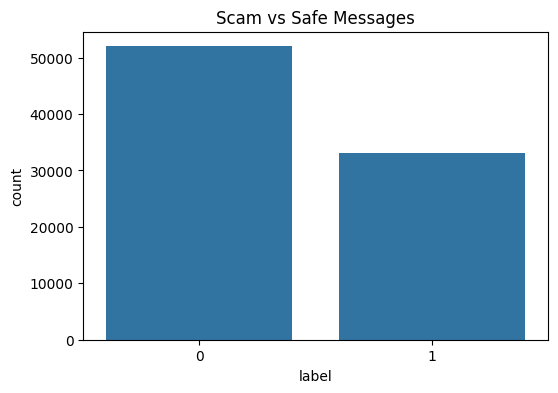

In [13]:
print("\nClass distribution")

print(

    data["label"]

    .value_counts()

)



plt.figure(figsize=(6,4))


sns.countplot(

    x=data["label"]

)


plt.title(
    "Scam vs Safe Messages"
)


plt.show()

Split Train-Test Dataset

In [14]:
X = data["message"]


y = data["label"]



X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)


Text Feature Extraction

In [15]:
print("\nConverting text into numbers...")


vectorizer = TfidfVectorizer(

    max_features=5000,

    ngram_range=(1,2)

)



X_train_vector = vectorizer.fit_transform(

    X_train

)



X_test_vector = vectorizer.transform(

    X_test

)


Converting text into numbers...


Train Multiple Models

In [16]:
models = {


"Naive Bayes":
MultinomialNB(),

"Logistic Regression":
LogisticRegression(
    max_iter=1000
),

"SVM":
LinearSVC()
}

results = {}
for name, model in models.items():
    print("\nTraining:", name)


    model.fit(
        X_train_vector,
        y_train
    )

    predictions = model.predict(
        X_test_vector
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )



    results[name] = {
        "model": model,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }



    print(
        classification_report(
            y_test,
            predictions
        )
    )


Training: Naive Bayes
              precision    recall  f1-score   support

           0       0.95      0.90      0.93     10400
           1       0.86      0.93      0.89      6619

    accuracy                           0.91     17019
   macro avg       0.91      0.92      0.91     17019
weighted avg       0.92      0.91      0.91     17019


Training: Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     10400
           1       0.94      0.94      0.94      6619

    accuracy                           0.95     17019
   macro avg       0.95      0.95      0.95     17019
weighted avg       0.95      0.95      0.95     17019


Training: SVM
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     10400
           1       0.95      0.95      0.95      6619

    accuracy                           0.96     17019
   macro avg       0.96      0.96      0.96     17019
weigh

Model Comparison

In [17]:
comparison = pd.DataFrame(

    {
        "Model":
        results.keys(),
        "Accuracy":
        [
        x["accuracy"]
        for x in results.values()
        ],

        "Precision":
        [
        x["precision"]
        for x in results.values()
        ],

        "Recall":
        [
        x["recall"]
        for x in results.values()
        ],

        "F1":
        [
        x["f1"]
        for x in results.values()
        ]
    }
)


print("\nMODEL PERFORMANCE SUMMARY:")
print(comparison.sort_values("F1", ascending=False))


os.makedirs("saved_models", exist_ok=True)
comparison.to_csv(
    "saved_models/model_comparison.csv",
    index=False
)

print("\nModel comparison saved.")


MODEL PERFORMANCE SUMMARY:
                 Model  Accuracy  Precision    Recall        F1
2                  SVM  0.959281   0.948939  0.946215  0.947575
1  Logistic Regression  0.953934   0.942515  0.938813  0.940660
0          Naive Bayes  0.913802   0.859375  0.930654  0.893595

Model comparison saved.


Save All Trained Models

In [18]:


# Save vectorizer once
joblib.dump(vectorizer, "saved_models/vectorizer.pkl")


# Save ALL trained models
for name, result in results.items():

    model = result["model"]

    filename = name.lower().replace(" ", "_") + ".pkl"

    path = os.path.join("saved_models", filename)

    joblib.dump(model, path)

    print(f"Saved model: {filename}")

Saved model: naive_bayes.pkl
Saved model: logistic_regression.pkl
Saved model: svm.pkl


Save Best Model

In [19]:
best_model_name = (
    comparison
    .sort_values("F1", ascending=False)
    .iloc[0]["Model"]
)

best_model = results[best_model_name]["model"]

best_model_path = "saved_models/best_model.pkl"

joblib.dump(best_model, best_model_path)

print("\nBEST MODEL:", best_model_name)
print("Saved as best_model.pkl")


BEST MODEL: SVM
Saved as best_model.pkl
